In [1]:
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from collections import OrderedDict
from tensorflow.keras import regularizers

# ====================================================
# 1. Global config
# ====================================================
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 1337

root_dir = Path("/data/classes/2025/fall/cs426/bartlecg5526/group_2/chest_xray")
train_dir = root_dir / "train"           # NORMAL / PNEUMONIA(/bacteria,virus)
test_dir  = root_dir / "test"            # NORMAL / PNEUMONIA(/bacteria,virus)
train_pneu_dir = train_dir / "PNEUMONIA" # bacteria / virus
test_pneu_dir  = test_dir / "PNEUMONIA"  # bacteria / virus

AUTOTUNE = tf.data.AUTOTUNE

2025-12-11 03:13:33.061317: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# ====================================================
# 2. Preprocess + prepare helper
# ====================================================
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def prepare(ds, shuffle=False, repeat=False):
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    if repeat:
        ds = ds.repeat()
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds



In [3]:
# ====================================================
# 3. Task A1: NORMAL vs PNEUMONIA
#    - use train/ (NORMAL, PNEUMONIA)
#    - test/ as fixed test set
#    - 10% of train used as validation
# ====================================================
# Load full training (unbatched) and test
train_full_A1 = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    seed=SEED,
    batch_size=None,
)

test_raw_A1 = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False,
    seed=SEED,
    batch_size=None,
)

print("A1 classes:", train_full_A1.class_names)  # ['NORMAL', 'PNEUMONIA']

total_train_A1 = train_full_A1.cardinality().numpy()
val_size_A1 = int(0.10 * total_train_A1)
train_size_A1 = total_train_A1 - val_size_A1

train_raw_A1 = train_full_A1.take(train_size_A1)
val_raw_A1   = train_full_A1.skip(train_size_A1)

# --- A1 subsets ---
total_train_A1 = train_raw_A1.cardinality().numpy()

def make_A1_subset(fraction):
    n = int(total_train_A1 * fraction)
    subset_raw = train_raw_A1.take(n)
    return prepare(subset_raw, shuffle=True)

train_A1_10  = make_A1_subset(0.10)
train_A1_25  = make_A1_subset(0.25)
train_A1_50  = make_A1_subset(0.50)
train_A1_100 = prepare(train_raw_A1, shuffle=True)  # full pool

val_A1 = prepare(val_raw_A1)
test_A1 = prepare(test_raw_A1)



Found 5232 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
A1 classes: ['NORMAL', 'PNEUMONIA']


2025-12-11 03:13:41.953507: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-11 03:13:42.050057: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:27:00.0, compute capability: 7.0


In [4]:
# ====================================================
# 4. Task A2: BACTERIA vs VIRUS (pneumonia only)
#    - use train/PNEUMONIA (bacteria, virus)
#    - test/PNEUMONIA as fixed test
#    - 10% of pneumonia-train used as validation
# ====================================================
train_full_A2 = tf.keras.utils.image_dataset_from_directory(
    train_pneu_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    seed=SEED,
    batch_size=None,
)

test_raw_A2 = tf.keras.utils.image_dataset_from_directory(
    test_pneu_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False,
    seed=SEED,
    batch_size=None,
)

print("A2 classes:", train_full_A2.class_names)  # ['bacteria', 'virus']

total_train_A2 = train_full_A2.cardinality().numpy()
val_size_A2 = int(0.10 * total_train_A2)
train_size_A2 = total_train_A2 - val_size_A2

train_raw_A2 = train_full_A2.take(train_size_A2)
val_raw_A2   = train_full_A2.skip(train_size_A2)

# --- A2 subsets ---
total_train_A2 = train_raw_A2.cardinality().numpy()

def make_A2_subset(fraction):
    n = int(total_train_A2 * fraction)
    subset_raw = train_raw_A2.take(n)
    return prepare(subset_raw, shuffle=True)

train_A2_10  = make_A2_subset(0.10)
train_A2_25  = make_A2_subset(0.25)
train_A2_50  = make_A2_subset(0.50)
train_A2_100 = prepare(train_raw_A2, shuffle=True)

val_A2 = prepare(val_raw_A2, repeat=True)
test_A2 = prepare(test_raw_A2)

val_steps_A2 = max(1, val_raw_A2.cardinality().numpy() // BATCH_SIZE)




Found 3883 files belonging to 2 classes.
Found 390 files belonging to 2 classes.
A2 classes: ['bacteria', 'virus']


In [7]:
# ====================================================
# Model C: Partial Fine-Tuning
# ====================================================
import tensorflow as tf
from tensorflow.keras import regularizers

def make_backbone_C():

    return tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet",
        pooling=None,
    )


def make_classifier_C(
    num_classes,
    modelB_weights_path,
    unfreeze_last_n=15,     
    lr=1e-5,                
    label_smoothing=0.05,
    l2_reg=1e-4,
):

    
    backbone = make_backbone_C()


    for layer in backbone.layers:
        layer.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))


    x = backbone(inputs)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(l2_reg),
    )(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(
        num_classes, activation="softmax"
    )(x)

    modelC = tf.keras.Model(inputs, outputs)


    modelC.load_weights(modelB_weights_path)

    
    for layer in backbone.layers[-unfreeze_last_n:]:
        if not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True


    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

    modelC.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=loss_fn,
        metrics=["accuracy"],
    )

    return modelC

In [8]:
# ====================================================
# 6C. Train Model C1 (NORMAL vs PNEUMONIA, Partial FT)
# ====================================================
EPOCHS = 20

c1_subsets = {
    "10%": train_A1_10,
    "25%": train_A1_25,
    "50%": train_A1_50,
    "100%": train_A1_100,
}

B1_weight_paths = {
    "10%": "B1_10%.h5",
    "25%": "B1_25%.h5",
    "50%": "B1_50%.h5",
    "100%": "B1_100%.h5",
}


c1_ft_config = {
    "10%":  dict(unfreeze_last_n=10, lr=5e-6),
    "25%":  dict(unfreeze_last_n=15, lr=5e-6),
    "50%":  dict(unfreeze_last_n=25, lr=1e-5),
    "100%": dict(unfreeze_last_n=35, lr=1e-5),
}

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

histories_C1 = {}
tests_C1 = {}
models_C1 = OrderedDict()

for name, train_ds in c1_subsets.items():
    print(f"\n=== C1 (Partial Fine-Tune) training on {name} dataset ===")

    cfg = c1_ft_config[name]

    # Build Model C with proper settings
    model = make_classifier_C(
        num_classes=2,
        modelB_weights_path=B1_weight_paths[name],
        unfreeze_last_n=cfg["unfreeze_last_n"],
        lr=cfg["lr"],
    )

    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_A1,
        callbacks=[early_stop],
    )

    histories_C1[name] = history.history
    tests_C1[name] = model.evaluate(test_A1, return_dict=True)
    models_C1[name] = model

print("C1 test metrics per subset:", tests_C1)


=== C1 (Partial Fine-Tune) training on 10% dataset ===
Epoch 1/20


2025-12-11 03:14:18.650278: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8401
2025-12-11 03:14:19.684188: I tensorflow/compiler/xla/service/service.cc:173] XLA service 0x5558b79c5840 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-11 03:14:19.684225: I tensorflow/compiler/xla/service/service.cc:181]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
2025-12-11 03:14:19.690043: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-11 03:14:19.794613: I tensorflow/compiler/jit/xla_compilation_cache.cc:477] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


15/15 [==============================] - 17s 741ms/step - loss: 0.1244 - accuracy: 0.9681 - val_loss: 0.1358 - val_accuracy: 0.9656
Epoch 2/20
15/15 [==============================] - 12s 667ms/step - loss: 0.1566 - accuracy: 0.9426 - val_loss: 0.1532 - val_accuracy: 0.9579
Epoch 3/20
15/15 [==============================] - 12s 652ms/step - loss: 0.1536 - accuracy: 0.9553 - val_loss: 0.1456 - val_accuracy: 0.9656
Epoch 4/20
15/15 [==============================] - 12s 651ms/step - loss: 0.1440 - accuracy: 0.9574 - val_loss: 0.1476 - val_accuracy: 0.9694
Epoch 5/20
15/15 [==============================] - 12s 640ms/step - loss: 0.1241 - accuracy: 0.9702 - val_loss: 0.1360 - val_accuracy: 0.9656
Epoch 6/20
20/20 [==============================] - 1s 59ms/step - loss: 0.3345 - accuracy: 0.8526

=== C1 (Partial Fine-Tune) training on 25% dataset ===
Epoch 1/20
37/37 [==============================] - 16s 287ms/step - loss: 0.1037 - accuracy: 0.9677 - val_loss: 0.1076 - val_accuracy: 0.967

In [9]:
# ====================================================
# 6C. Train Model C2 (BACTERIAL vs VIRAL, Partial FT)
# ====================================================
EPOCHS = 20

c2_subsets = {
    "10%": train_A2_10,
    "25%": train_A2_25,
    "50%": train_A2_50,
    "100%": train_A2_100,
}

B2_weight_paths = {
    "10%": "B2_10%.h5",
    "25%": "B2_25%.h5",
    "50%": "B2_50%.h5",
    "100%": "B2_100%.h5",
}


c2_ft_config = {
    "10%":  dict(unfreeze_last_n=8,  lr=5e-6),
    "25%":  dict(unfreeze_last_n=12, lr=5e-6),
    "50%":  dict(unfreeze_last_n=20, lr=1e-5),
    "100%": dict(unfreeze_last_n=30, lr=1e-5),
}

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

histories_C2 = {}
tests_C2 = {}
models_C2 = OrderedDict()

for name, train_ds in c2_subsets.items():
    print(f"\n=== C2 (Partial Fine-Tune) training on {name} dataset ===")

    cfg = c2_ft_config[name]

    model = make_classifier_C(
        num_classes=2,
        modelB_weights_path=B2_weight_paths[name],
        unfreeze_last_n=cfg["unfreeze_last_n"],
        lr=cfg["lr"],
    )

    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_A2,
        validation_steps=val_steps_A2,
        callbacks=[early_stop],
    )

    histories_C2[name] = history.history
    tests_C2[name] = model.evaluate(test_A2, return_dict=True)
    models_C2[name] = model

print("C2 test metrics per subset:", tests_C2)


=== C2 (Partial Fine-Tune) training on 10% dataset ===
Epoch 1/20
11/11 [==============================] - 9s 515ms/step - loss: 0.5478 - accuracy: 0.7450 - val_loss: 0.6213 - val_accuracy: 0.7083
Epoch 2/20
11/11 [==============================] - 5s 405ms/step - loss: 0.5468 - accuracy: 0.7794 - val_loss: 0.5547 - val_accuracy: 0.7214
Epoch 3/20
11/11 [==============================] - 5s 399ms/step - loss: 0.5388 - accuracy: 0.7335 - val_loss: 0.5548 - val_accuracy: 0.7266
Epoch 4/20
11/11 [==============================] - 5s 413ms/step - loss: 0.5513 - accuracy: 0.7507 - val_loss: 0.5743 - val_accuracy: 0.7266
Epoch 5/20
11/11 [==============================] - 5s 397ms/step - loss: 0.4840 - accuracy: 0.7822 - val_loss: 0.4978 - val_accuracy: 0.7865
Epoch 6/20
11/11 [==============================] - 5s 387ms/step - loss: 0.5194 - accuracy: 0.7450 - val_loss: 0.5219 - val_accuracy: 0.7734
Epoch 7/20
11/11 [==============================] - 5s 395ms/step - loss: 0.5341 - accuracy:

13/13 [==============================] - 0s 26ms/step - loss: 0.3623 - accuracy: 0.8795
C2 test metrics per subset: {'10%': {'loss': 0.45205727219581604, 'accuracy': 0.8102564215660095}, '25%': {'loss': 0.39033833146095276, 'accuracy': 0.8717948794364929}, '50%': {'loss': 0.3506709933280945, 'accuracy': 0.8743589520454407}, '100%': {'loss': 0.3623378276824951, 'accuracy': 0.879487156867981}}


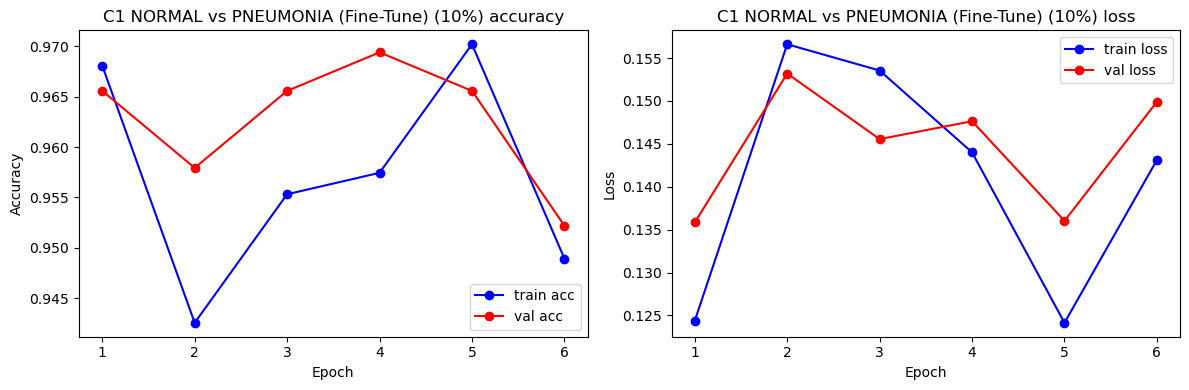

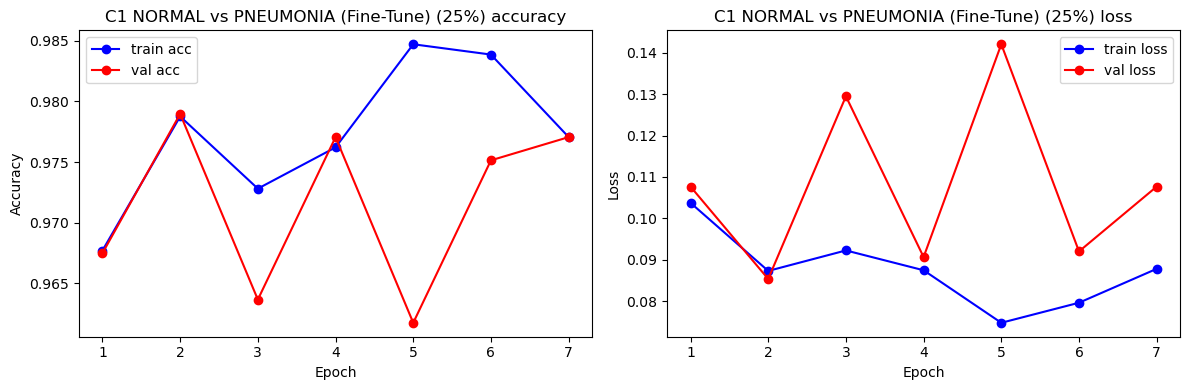

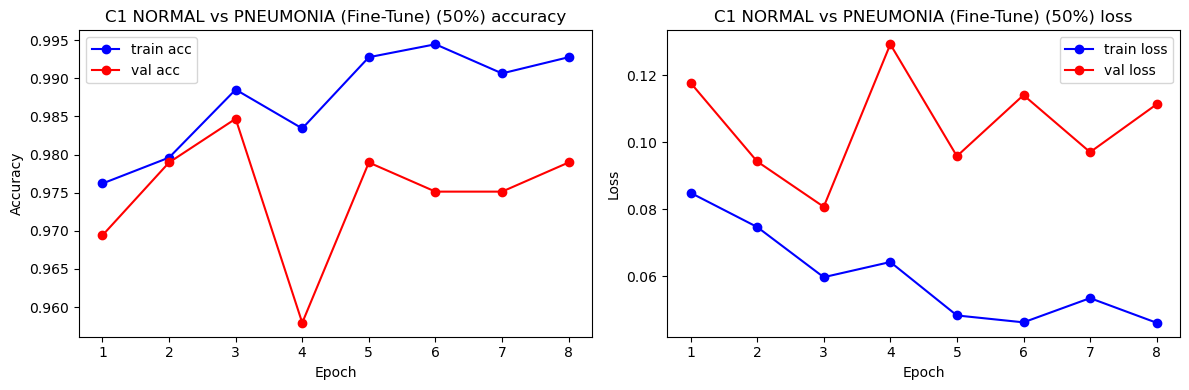

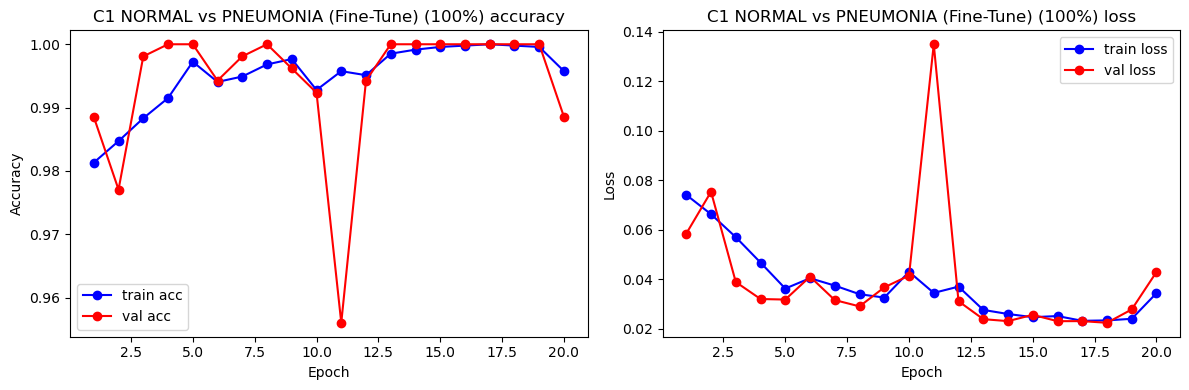

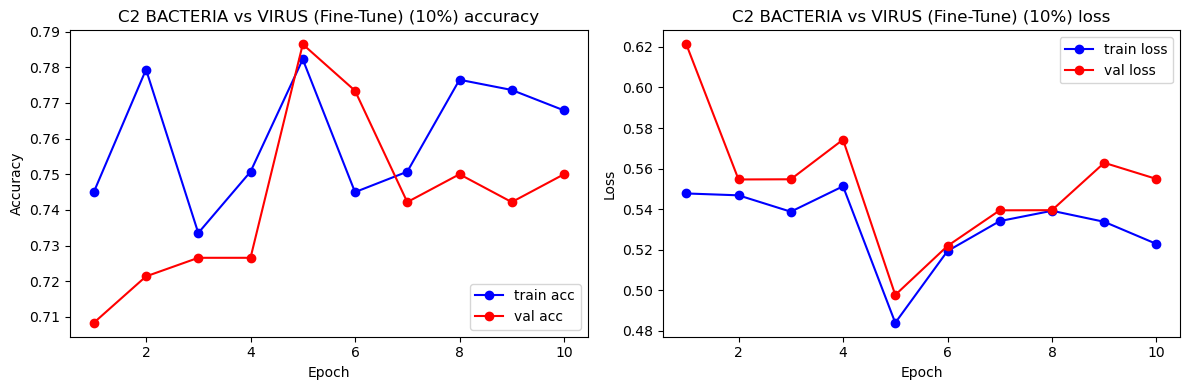

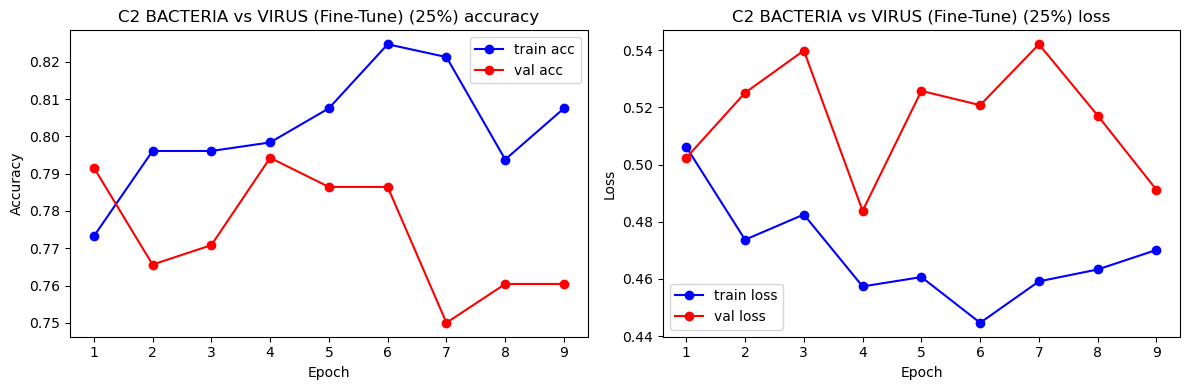

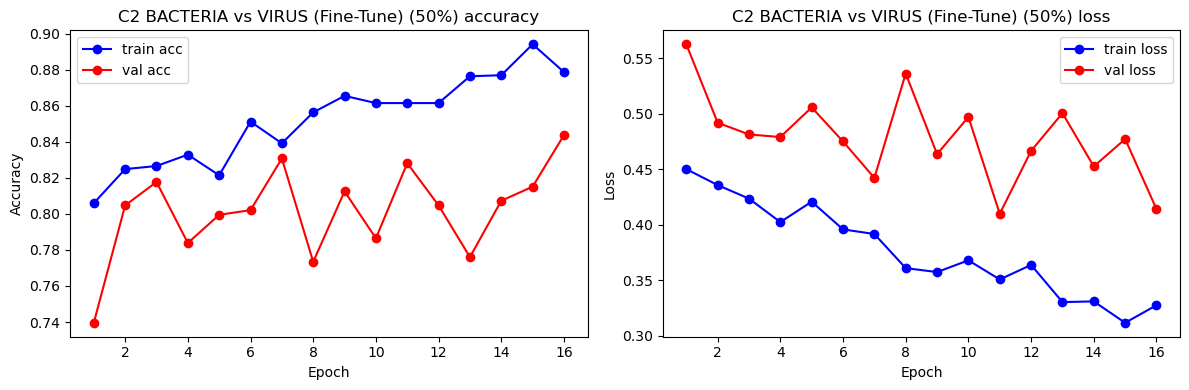

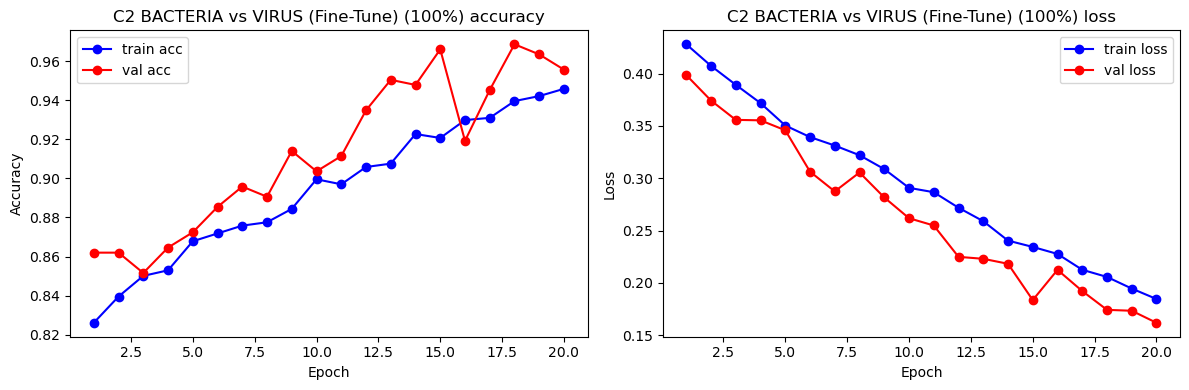

In [11]:
# ====================================================
# Plot histories for all subsets
# ====================================================

# small wrapper so plot_history can use .history like a Keras History object
class HistoryWrapper:
    def __init__(self, hist_dict):
        self.history = hist_dict

# existing plotting function (unchanged)
def plot_history(history, title_prefix="Model"):
    acc = history.history.get("accuracy", [])
    val_acc = history.history.get("val_accuracy", [])
    loss = history.history.get("loss", [])
    val_loss = history.history.get("val_loss", [])

    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    if acc:
        epochs_acc = range(1, len(acc) + 1)
        plt.plot(epochs_acc, acc, "bo-", label="train acc")
    if val_acc:
        epochs_val_acc = range(1, len(val_acc) + 1)
        plt.plot(epochs_val_acc, val_acc, "ro-", label="val acc")
    plt.title(f"{title_prefix} accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    if loss:
        epochs_loss = range(1, len(loss) + 1)
        plt.plot(epochs_loss, loss, "bo-", label="train loss")
    if val_loss:
        epochs_val_loss = range(1, len(val_loss) + 1)
        plt.plot(epochs_val_loss, val_loss, "ro-", label="val loss")
    plt.title(f"{title_prefix} loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


# ====================================================
# Plot C1 (Frozen MobileNetV2) histories
# ====================================================
for frac, hist_dict in histories_C1.items():
    plot_history(
        HistoryWrapper(hist_dict),
        title_prefix=f"C1 NORMAL vs PNEUMONIA (Fine-Tune) ({frac})"
    )
# ====================================================
# Plot C2 (Frozen MobileNetV2) histories
# ====================================================
for frac, hist_dict in histories_C2.items():
    plot_history(
        HistoryWrapper(hist_dict),
        title_prefix=f"C2 BACTERIA vs VIRUS (Fine-Tune) ({frac})"
    )


In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

def eval_with_confusion(model, test_ds, class_names, title="Model"):
    y_true = []
    y_pred = []

    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        preds_labels = np.argmax(preds, axis=1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds_labels)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    print(f"\n{title} - Confusion matrix")
    print(cm)

    print(f"\n{title} - Classification report")
    print(classification_report(y_true, y_pred, target_names=class_names))

In [13]:
class_names_A1 = ["NORMAL", "PNEUMONIA"]
class_names_A2 = ["BACTERIA", "VIRUS"]

# C1: NORMAL vs PNEUMONIA (Frozen Backbone)
for name, model in models_C1.items():
    eval_with_confusion(
        model,
        test_A1,
        class_names_A1,
        title=f"C1 Frozen ({name} train pool)"
    )

# C2: BACTERIA vs VIRUS (Frozen Backbone)
for name, model in models_C2.items():
    eval_with_confusion(
        model,
        test_A2,
        class_names_A2,
        title=f"C2 Frozen ({name} train pool)"
    )



C1 Frozen (10% train pool) - Confusion matrix
[[143  91]
 [  1 389]]

C1 Frozen (10% train pool) - Classification report
              precision    recall  f1-score   support

      NORMAL       0.99      0.61      0.76       234
   PNEUMONIA       0.81      1.00      0.89       390

    accuracy                           0.85       624
   macro avg       0.90      0.80      0.83       624
weighted avg       0.88      0.85      0.84       624


C1 Frozen (25% train pool) - Confusion matrix
[[175  59]
 [  1 389]]

C1 Frozen (25% train pool) - Classification report
              precision    recall  f1-score   support

      NORMAL       0.99      0.75      0.85       234
   PNEUMONIA       0.87      1.00      0.93       390

    accuracy                           0.90       624
   macro avg       0.93      0.87      0.89       624
weighted avg       0.92      0.90      0.90       624


C1 Frozen (50% train pool) - Confusion matrix
[[188  46]
 [  1 389]]

C1 Frozen (50% train pool) - Cl